# Heart Disease UCI：心疾患アウトカムとの関連

run_id: `v020-exp-33`。単変量差と多変量関連を区別する探索的・非因果分析。認証情報を記録しない。

In [1]:
from pathlib import Path
import os, json, hashlib, io, contextlib, inspect, zipfile
from datetime import datetime, timezone
import numpy as np
import pandas as pd
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle, language_router, data_definition, analysis_assumptions, data_quality, sensitivity, eda, cleaning, visualization, notebook_audit, insight_engine
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
handle = pm.resolve_project('kaggle-v020-kaggle-exp-33-heart-disease')
run_id = 'v020-exp-33'
lifecycle.register_run(run_id, handle.notebook_path)
data_dir = pm.ensure_data_dir(handle)
print('言語:', language_router.detect_language('心疾患の関連を分析してください'))
print('run_id:', run_id)
print('Notebook:', handle.notebook_path)
import nbformat
from dataclasses import asdict
def record_lifecycle(event, **extra):
    status=asdict(lifecycle.get_run_status(run_id))
    payload={'time_utc':datetime.now(timezone.utc).isoformat(),'event':event,**status,**extra}
    with (data_dir/'lifecycle-events.jsonl').open('a',encoding='utf-8') as f:
        f.write(json.dumps(payload,ensure_ascii=False,default=str)+'\n')
@contextlib.contextmanager
def execution_phase(label):
    if lifecycle.is_cancel_requested(run_id):
        lifecycle.mark_failed(run_id)
        record_lifecycle('cancelled',phase=label)
        raise RuntimeError('runの取消要求を確認')
    lifecycle.mark_execution_start(run_id)
    record_lifecycle('execution_start',phase=label)
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(run_id)
        record_lifecycle('failed',phase=label,error_type=type(exc).__name__)
        raise
    finally:
        lifecycle.mark_execution_end(run_id)
        record_lifecycle('execution_end',phase=label)
record_lifecycle('registered')


言語: ja
run_id: v020-exp-33
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-33-heart-disease/notebooks/kaggle-v020-kaggle-exp-33-heart-disease.ipynb


In [2]:
with execution_phase('cell-2'):
    pass
    acquisition = {'status':'pending', 'search':'heart disease uci'}
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api = KaggleApi()
            api.authenticate()
            found = api.dataset_list(search='heart disease uci')
        candidates = [{'slug':str(d.ref),'title':str(d.title)} for d in found]
        print('Kaggle検索結果:', json.dumps(candidates,ensure_ascii=False))
        preferred = 'redwankarimsony/heart-disease-data'
        if preferred not in [d['slug'] for d in candidates]:
            raise RuntimeError('Expected corresponding UCI dataset was not returned')
        slug = preferred
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            listing = api.dataset_list_files(slug)
        files = [str(f.name) for f in listing.files]
        print('ファイル一覧:', files)
        if 'heart_disease_uci.csv' not in files:
            raise RuntimeError('Corresponding heart.csv not found')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(slug, 'heart_disease_uci.csv', path=str(data_dir), force=True, quiet=True)
        csv_path = data_dir / 'heart_disease_uci.csv'
        if not csv_path.exists():
            archive = data_dir / 'heart_disease_uci.csv.zip'
            if not archive.exists():
                raise FileNotFoundError('Downloaded CSV/ZIP absent')
            with zipfile.ZipFile(archive) as z:
                csv_path.write_bytes(z.read('heart_disease_uci.csv'))
        acquisition.update(status='success',slug=slug,filename='heart_disease_uci.csv',retrieved_at=datetime.now(timezone.utc).isoformat(),sha256=hashlib.sha256(csv_path.read_bytes()).hexdigest(),transport='Kaggle Python SDK')
    except Exception as exc:
        # SDKの例外本文には認証情報が入り得るため、種類のみ公開する。
        acquisition.update(status='failed',error_type=type(exc).__name__,failure_reason='Kaggle認証・検索・取得のいずれかに失敗。秘密保護のため例外本文は非表示。')
        paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        if paper.exists():
            paper_text = paper.read_text(encoding='utf-8')
            lines = paper_text.splitlines()
            for i,line in enumerate(lines):
                if 'heart' in line.lower() or '心疾患' in line:
                    print('white-paper該当箇所:', '\n'.join(lines[max(0,i-2):i+3]))
        else:
            print('フォールバック文書が存在しません。')
    finally:
        pass
    print('取得記録:',json.dumps(acquisition,ensure_ascii=False,indent=2))

Kaggle検索結果: [{"slug": "redwankarimsony/heart-disease-data", "title": "UCI Heart Disease Data"}, {"slug": "cherngs/heart-disease-cleveland-uci", "title": "Heart Disease Cleveland UCI"}, {"slug": "ketangangal/heart-disease-dataset-uci", "title": "Heart Disease Dataset UCI"}, {"slug": "hamnawaseem112222222/uci-heart-disease-dataset", "title": "UCI Heart Disease Dataset"}, {"slug": "mragpavank/heart-diseaseuci", "title": "Heart Disease-UCI"}, {"slug": "thisishusseinali/uci-heart-disease-data", "title": "UCI Heart Disease Data"}, {"slug": "priyanka841/heart-disease-prediction-uci", "title": "Heart Disease Prediction UCI"}, {"slug": "rcratos/heart-disease-data-compiled-from-uci", "title": "Heart Disease Data Compiled from UCI"}, {"slug": "fedesoriano/heart-failure-prediction", "title": "Heart Failure Prediction Dataset"}, {"slug": "ineubytes/heart-disease-dataset", "title": "Heart-Disease-Dataset"}, {"slug": "kaggleprollc/heart-disease-and-conditions-data", "title": "Heart Diseases and Condi

## 取得データ・欠損・符号化
検索結果でUCI由来と明記された公開データを選択。4施設を含む版を使い、別の303行版の符号を流用しない。

In [3]:
with execution_phase('cell-4'):
    pass
    if acquisition['status'] != 'success':
        lifecycle.mark_failed(run_id)
        raise RuntimeError('取得失敗：対応CSVなし。推測データでの分析は禁止。')
    from ai_data_scientist import ingestion
    from dataclasses import asdict
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_metadata(slug, path=str(data_dir))
    metadata_path = data_dir / 'dataset-metadata.json'
    metadata = json.loads(metadata_path.read_text())
    description = metadata['info'].get('description','')
    print('Kaggle公開データ説明（定義確認）:',description)
    from urllib.request import urlopen
    uci_dictionary_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/heart-disease.names'
    try:
        with urlopen(uci_dictionary_url,timeout=30) as response:
            uci_dictionary = response.read().decode('utf-8',errors='replace')
        (data_dir/'heart-disease.names').write_text(uci_dictionary,encoding='utf-8')
        print('UCI辞書URL:',uci_dictionary_url)
        print('辞書SHA256:',hashlib.sha256(uci_dictionary.encode()).hexdigest())
        for i,line in enumerate(uci_dictionary.splitlines()):
            if 'num:' in line.lower() or 'thal:' in line.lower() or 'diameter' in line.lower() or 'values 1,2,3,4' in line.lower() or 'Cleveland: 164' in line:
                print('UCI定義抜粋:', '\n'.join(uci_dictionary.splitlines()[i:i+5]))
    except (OSError,UnicodeError) as exc:
        uci_dictionary = ''
        print('UCI辞書取得失敗:',type(exc).__name__,'エンドポイント定義は未検証として制限する')
    
    loaded = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(csv_path)))
    raw = loaded.dataframe if hasattr(loaded,'dataframe') else loaded.df
    print('データ形状:',raw.shape)
    print('欠損:', raw.isna().sum().to_dict())
    print('符号化:',{c:raw[c].value_counts(dropna=False).to_dict() for c in raw if raw[c].nunique()<15})
    print('重複ID:',raw.id.duplicated().sum(),'ID以外の完全重複:',raw.drop(columns='id').duplicated().sum())
    profile = eda.explore(raw)
    print('EDA:',str(profile)[:12000])
    print('施設別件数・num陽性率:',raw.assign(y=(raw.num>0).astype(int)).groupby('dataset').y.agg(['count','mean']).to_string())
    print('施設別欠損率:',raw.groupby('dataset').apply(lambda d:d.isna().mean(),include_groups=False).round(3).to_string())
    pass

Kaggle公開データ説明（定義確認）: ### Context

This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from thi

## データ定義・分析前提manifestと意味的品質検査
未確認の単位や臨床閾値はinferred/unknownとして公開する。0値を欠損として扱う妥当性を検証する。

In [4]:
with execution_phase('cell-6'):
    pass
    FV = data_definition.FieldValue
    source_info = {'url':FV('https://www.kaggle.com/datasets/'+slug,'verified','Kaggle API'),'sha256':FV(acquisition['sha256'],'verified','取得ファイル'),'retrieved_at':FV(acquisition['retrieved_at'],'verified','UTC')}
    meaning = {
    'id':('レコードID','なし'),'age':('年齢','年'),'sex':('記録された性別','Male/Female'),'dataset':('データ収集施設','Cleveland/Hungary/Switzerland/VA Long Beach'),
    'cp':('胸痛型','文字列カテゴリ'),'trestbps':('安静時血圧','mmHg'),'chol':('血清コレステロール','mg/dL'),'fbs':('空腹時血糖120 mg/dL超','bool'),'restecg':('安静時心電図','文字列カテゴリ'),'thalch':('運動時最大心拍数','bpm'),'exang':('運動誘発狭心症','bool'),'oldpeak':('運動による安静時に対するST低下','source未確認'),'slope':('運動ピークST部分の傾き','文字列カテゴリ'),'ca':('透視で着色された主要血管数','0–3'),'thal':('タリウム負荷検査','normal/fixed defect/reversable defect'),'num':('心疾患診断の元の0–4符号','0:なし、1–4:ありとして二値化')}
    # Kaggle公開説明に語が確認できる項目のみverifiedとする。単位の根拠は別管理。
    variables = {}
    for c,(definition,unit) in meaning.items():
        confirmed = c.lower() in description.lower()
        variables[c] = {'meaning':FV(definition,'verified' if confirmed else 'inferred','Kaggle公開説明と列名'),'unit_or_encoding':FV(unit,'inferred','UCI慣例と観測値'),'observed_values':FV(sorted(map(str,raw[c].dropna().unique())) if raw[c].nunique()<15 else '連続値','verified','CSV')}
    variables['num']['clinical_endpoint'] = FV('血管造影上の狭窄判定に基づくUCI診断との対応。将来の発症・死亡ではない。閾値の本CSVでの独立検証は未実施','inferred','UCI由来の説明')
    for c in ['age','trestbps','chol','fbs','ca','sex','cp']:
        variables[c]['unit_or_encoding'] = FV(meaning[c][1],'verified','Kaggle metadata.info.description')
    variables['oldpeak']['unit_or_encoding'] = FV('ST低下の記録尺度、mm換算の独立確認なし','unknown','単位の明記なし')
    variables['thal']['meaning'] = FV('負荷検査の欠損型分類。thalassemiaというKaggle導入部の記述と混同しない','verified' if 'thal:' in uci_dictionary else 'inferred',uci_dictionary_url)
    variables['num']['clinical_endpoint'] = FV('血管造影診断のnum: 0は血管径狭窄50%未満、1は50%超。原データの1–4を疾患ありへ集約。将来発症・死亡でない。','verified' if 'diameter narrowing' in uci_dictionary else 'inferred',uci_dictionary_url)
    definition_manifest = data_definition.build_manifest(source_info, {'population':FV('4施設の診断用臨床標本、920レコード','verified','CSV'),'sampling_frame':FV(None,'unknown'),'time_order':FV(None,'unknown')}, variables, transformations=('y = 1[num > 0]','血圧・コレステロール0を欠損扱い','カテゴリをダミー符号化、IDは説明変数にしない'))
    print('データ定義manifest:',json.dumps(asdict(definition_manifest),ensure_ascii=False,default=str,indent=2))
    print('未確定定義（unknown）:',definition_manifest.unresolved_fields())
    print('推定に留まる定義（inferred）:',[(c,k,v.value) for c,fields in definition_manifest.variables.items() for k,v in fields.items() if v.status=='inferred'])
    schema = {'id':{'unique':True,'not_null':True},'age':{'min':18,'max':100,'not_null':True},'trestbps':{'min':50,'max':260},'chol':{'min':50,'max':700},'thalch':{'min':30,'max':240},'oldpeak':{'min':-5,'max':10},'ca':{'allowed':[0,1,2,3]},'num':{'allowed':[0,1,2,3,4],'not_null':True},'sex':{'allowed':['Male','Female']},'cp':{'allowed':['typical angina','atypical angina','non-anginal','asymptomatic']}}
    schema.update({'dataset':{'allowed':['Cleveland','Hungary','Switzerland','VA Long Beach'],'not_null':True},'restecg':{'allowed':['normal','lv hypertrophy','st-t abnormality']},'fbs':{'allowed':[True,False]},'exang':{'allowed':[True,False]},'slope':{'allowed':['flat','upsloping','downsloping']},'thal':{'allowed':['normal','fixed defect','reversable defect']}})
    semantic_anomalies = data_quality.detect_anomalies(raw,schema=schema)
    print('意味的異常:',semantic_anomalies)
    print('ゼロ値件数:', {c:int(raw[c].eq(0).sum()) for c in ['trestbps','chol']})
    print('oldpeak負値:',int(raw.oldpeak.lt(0).sum()),'ST上昇を表す可能性があり自動削除しない')
    df = raw.copy()
    for c in ['trestbps','chol']: df.loc[df[c].eq(0),c] = np.nan
    df['y'] = (df.num>0).astype(int)
    df['age10'] = df.age/10
    df['bp10'] = df.trestbps/10
    df['chol50'] = df.chol/50
    df['hr10'] = df.thalch/10
    for c in ['fbs','exang']: df[c] = df[c].map({True:1,False:0})
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={'outcome':'num>0','models':'探索的ロジスティック回帰'},causal_scope='associational',sampling={'frame':'臨床診断標本、母集団抽出確率不明','n':len(raw),'seed':20261002},assumptions=(
    analysis_assumptions.Assumption('endpoint','num>0が疾患ありを表す（元辞書との対応、Kaggle変換は独立照合なし）','verified' if 'diameter narrowing' in uci_dictionary else 'assumed',impact_if_false='結果の臨床方向が逆転',conclusion_critical=True),
    analysis_assumptions.Assumption('independent','レコード間は独立。患者の再受診は識別不能','assumed',impact_if_false='CIが過小',conclusion_critical=True),
    analysis_assumptions.Assumption('zeros','血圧・cholの0は生理的真値でないため欠損化','tested',impact_if_false='欠損化による選択'),
    analysis_assumptions.Assumption('selection','完全ケースが元の対象を代表する','assumed',impact_if_false='選択バイアス',conclusion_critical=True),
    analysis_assumptions.Assumption('no-causal','無交絡と時間順序の識別はできない','verified',impact_if_false='因果効果は推定不可')))
    print('分析前提manifest:',json.dumps(asdict(assumption_manifest),ensure_ascii=False,default=str,indent=2))
    print('前提検査の全所見:',analysis_assumptions.check_manifest(assumption_manifest))
    print('適用しない機能: 独立参照データがないためvalidate_anomalies/compare_datasetsは不使用。同CSVの施設比較は外部検証ではない。時系列予測、因果同定、AutoMLは目的と時間情報の欠如により適用外。')
    pass

データ定義manifest: {
  "source": {
    "url": {
      "value": "https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data",
      "status": "verified",
      "source": "Kaggle API"
    },
    "sha256": {
      "value": "574f2fa2b43012fa25fca4fcdb36bd7c6bccdd0af4242f6c0e4c8633c5a072ae",
      "status": "verified",
      "source": "取得ファイル"
    },
    "retrieved_at": {
      "value": "2026-10-01T21:51:05.663946+00:00",
      "status": "verified",
      "source": "UTC"
    }
  },
  "dataset_scope": {
    "population": {
      "value": "4施設の診断用臨床標本、920レコード",
      "status": "verified",
      "source": "CSV"
    },
    "sampling_frame": {
      "value": null,
      "status": "unknown",
      "source": null
    },
    "time_order": {
      "value": null,
      "status": "unknown",
      "source": null
    }
  },
  "variables": {
    "id": {
      "meaning": {
        "value": "レコードID",
        "status": "verified",
        "source": "Kaggle公開説明と列名"
      },
      "unit_or_encoding": {
  

## 単変量差と多変量関連
単変量は疾患有無の群差、主モデルは施設を含む相互調整OR。カテゴリは連続得点として扱わない。主モデルから欠損の大きいslope/ca/thalを除外し、後で施設限定解析を行う。p値で変数選択しない。

In [5]:
with execution_phase('cell-8'):
    pass
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from scipy import stats
    from statsmodels.stats.multitest import multipletests
    continuous = ['age','trestbps','chol','thalch','oldpeak']
    categorical = ['sex','cp','fbs','restecg','exang','slope','ca','thal','dataset']
    uni = []
    for c in continuous:
        a=df.loc[df.y.eq(0),c].dropna(); b=df.loc[df.y.eq(1),c].dropna()
        p=stats.mannwhitneyu(a,b,alternative='two-sided').pvalue
        uni.append({'feature':c,'n0':len(a),'n1':len(b),'median0':a.median(),'median1':b.median(),'mean0':a.mean(),'mean1':b.mean(),'test':'Mann–Whitney','p':p})
    for c in categorical:
        tab=pd.crosstab(df[c],df.y)
        chi,p,dof,expected=stats.chi2_contingency(tab)
        uni.append({'feature':c,'n0':int(tab[0].sum()),'n1':int(tab[1].sum()),'test':'chi-square','p':p,'min_expected':expected.min()})
    uni=pd.DataFrame(uni); uni['q_BH']=multipletests(uni.p,method='fdr_bh')[1]
    print('単変量群差（欠損は項目別除外・探索的FDR）:');print(uni.to_string(index=False))
    for c in categorical:
        print('カテゴリ別陽性率',c,df.groupby(c,dropna=False).y.agg(['count','mean']).to_string())
    terms = ['age10',"C(sex, Treatment(reference='Female'))", "C(cp, Treatment(reference='typical angina'))",'bp10','chol50','fbs',"C(restecg, Treatment(reference='normal'))",'hr10','exang','oldpeak']
    core = 'y ~ '+' + '.join(terms)
    formula = core + " + C(dataset, Treatment(reference='Cleveland'))"
    needed=['y','age10','sex','cp','bp10','chol50','fbs','restecg','hr10','exang','oldpeak','dataset']
    cc = df.dropna(subset=needed).copy()
    fit = smf.glm(formula,data=cc,family=sm.families.Binomial()).fit()
    fit_nosite = smf.glm(core,data=cc,family=sm.families.Binomial()).fit()
    def or_table(model):
        ci=model.conf_int()
        return pd.DataFrame({'OR':np.exp(model.params),'CI_low':np.exp(ci[0]),'CI_high':np.exp(ci[1]),'p':model.pvalues})
    adjusted=or_table(fit)
    print('モデル仕様:',formula)
    print('解析件数:',len(cc),'陽性:',int(cc.y.sum()),'パラメータ数:',len(fit.params),'収束:',fit.converged)
    print('多変量調整OR/95%CI:');print(adjusted.to_string())
    print('同じ完全ケースで施設未調整OR:');print(or_table(fit_nosite).to_string())
    print('完全ケース選択:',df.assign(included=df.index.isin(cc.index)).groupby(['dataset','included']).y.agg(['count','mean']).to_string())
    print('設計行列rank:',np.linalg.matrix_rank(fit.model.exog),'列数:',fit.model.exog.shape[1],'条件数:',np.linalg.cond(fit.model.exog))
    print('ORはリスク比でない。主モデルは診断時の相互調整関連であり、cp/exang/oldpeak等を交絡因子と断定しない。')
    pass

単変量群差（欠損は項目別除外・探索的FDR）:
 feature  n0  n1  median0  median1      mean0      mean1         test            p  min_expected         q_BH
     age 411 509     51.0    57.00  50.547445  55.903733 Mann–Whitney 1.288873e-18           NaN 2.004914e-18
trestbps 391 469    130.0   130.00 129.913043 134.264392 Mann–Whitney 1.299623e-03           NaN 1.399595e-03
    chol 372 346    233.0   248.00 240.158602 254.008671 Mann–Whitney 6.970252e-04           NaN 8.131961e-04
  thalch 391 474    151.0   128.00 148.800512 128.261603 Mann–Whitney 9.025960e-32           NaN 2.527269e-31
 oldpeak 390 468      0.0     1.05   0.418205   1.262607 Mann–Whitney 8.512669e-32           NaN 2.527269e-31
     sex 411 509      NaN      NaN        NaN        NaN   chi-square 2.485453e-20     86.667391 4.970906e-20
      cp 411 509      NaN      NaN        NaN        NaN   chi-square 7.036525e-58     20.550000 9.851135e-57
     fbs 397 433      NaN      NaN        NaN        NaN   chi-square 5.971604e-05     66.007229

## 反復依頼履歴

### 反復1
**追加依頼（原文）**

主解析からSwitzerlandが全件脱落しています。コレステロール0値と欠損の施設分布を確認し、cholとfbsを除いた施設調整モデル、0値をそのまま使うモデル、同じ標本でcholだけを除いたモデルを比較して、コレステロールの関連と他の主要関連が標本選択に依存するか調べてください。

**選定理由:** 初回の661完全ケースからSwitzerlandが全件脱落し、cholのゼロ処理で単変量の方向が逆転する。結論を変え得る問題を優先する。証拠は直後セルの施設別ゼロ分布・モデル比較・SensitivityReport。

In [6]:
with execution_phase('cell-10'):
    pass
    print('反復1の依頼原文:','主解析からSwitzerlandが全件脱落しています。コレステロール0値と欠損の施設分布を確認し、cholとfbsを除いた施設調整モデル、0値をそのまま使うモデル、同じ標本でcholだけを除いたモデルを比較して、コレステロールの関連と他の主要関連が標本選択に依存するか調べてください。')
    print('施設別cholゼロ:',raw.assign(zero=raw.chol.eq(0)).groupby('dataset').zero.agg(['sum','count']).to_string())
    print('ゼロ含むchol群平均:',raw.groupby(raw.num.gt(0)).chol.mean().to_dict())
    print('ゼロを欠損化後のchol群平均:',df.groupby('y').chol.mean().to_dict())
    reduced_terms=[t for t in terms if t not in ['chol50','fbs']]
    reduced_formula='y ~ '+' + '.join(reduced_terms)+" + C(dataset, Treatment(reference='Cleveland'))"
    reduced_needed=[c for c in needed if c not in ['chol50','fbs']]
    reduced_data=df.dropna(subset=reduced_needed).copy()
    reduced_fit=smf.glm(reduced_formula,data=reduced_data,family=sm.families.Binomial()).fit()
    same_nochol_formula='y ~ '+' + '.join(t for t in terms if t!='chol50')+" + C(dataset, Treatment(reference='Cleveland'))"
    same_fit=smf.glm(same_nochol_formula,data=cc,family=sm.families.Binomial()).fit()
    zeros_data=df.copy(); zeros_data['chol50']=raw.chol/50;zeros_data['bp10']=raw.trestbps/10
    zeros_fit=smf.glm(formula,data=zeros_data.dropna(subset=needed),family=sm.families.Binomial()).fit()
    print('各モデル件数:',{'main':len(cc),'reduced_all_sites':len(reduced_data),'zeros_literal':int(zeros_fit.nobs)})
    print('縮小モデル施設内訳:',reduced_data.groupby('dataset').y.agg(['count','mean']).to_string())
    print('全施設を戻した縮小モデル:');print(or_table(reduced_fit).to_string())
    print('0値を真値扱いしたモデル（推奨しない）:');print(or_table(zeros_fit).to_string())
    selected_terms=["C(sex, Treatment(reference='Female'))[T.Male]", "C(cp, Treatment(reference='typical angina'))[T.asymptomatic]",'age10','hr10','exang','oldpeak']
    comparison=pd.DataFrame({name:np.exp(m.params).reindex(selected_terms) for name,m in [('main',fit),('reduced_same_sample',same_fit),('reduced_all_sites',reduced_fit),('literal_zeros',zeros_fit)]})
    print('調整関連の比較OR:');print(comparison.to_string())
    spec_models={'main':fit,'reduced_same':same_fit,'reduced_all':reduced_fit,'literal_zeros':zeros_fit}
    plan=sensitivity.SensitivityPlan(parameter_grid={'specification':list(spec_models)},max_runs=4)
    stability1={}
    for term in ['exang','oldpeak','age10','hr10']:
        report=sensitivity.run_sensitivity(plan,lambda specification:float(np.exp(spec_models[specification].params[term])),stability_tolerance=0.25)
        stability1[term]=asdict(report)
    print('感度検査（OR相対偏差25%閾値・4仕様）:',json.dumps(stability1,ensure_ascii=False,indent=2))
    print('反復1結果: 血清cholゼロを真値扱いする臨床解釈は不可。施設/欠損による推定対象の変化と、同標本での調整セットの変化を別々に評価。ORの非可約性でも調整前後差が生じるため、差を全て交絡の除去と断定しない。残る限界: 欠損機構MAR/MNARは検証不能、縮小モデルは脂質/血糖で未調整。')
    pass

反復1の依頼原文: 主解析からSwitzerlandが全件脱落しています。コレステロール0値と欠損の施設分布を確認し、cholとfbsを除いた施設調整モデル、0値をそのまま使うモデル、同じ標本でcholだけを除いたモデルを比較して、コレステロールの関連と他の主要関連が標本選択に依存するか調べてください。
施設別cholゼロ:                sum  count
dataset                  
Cleveland        0    304
Hungary          0    293
Switzerland    123    123
VA Long Beach   49    200
ゼロ含むchol群平均: {False: 227.90561224489795, True: 176.47991967871485}
ゼロを欠損化後のchol群平均: {0: 240.15860215053763, 1: 254.00867052023122}
各モデル件数: {'main': 661, 'reduced_all_sites': 851, 'zeros_literal': 740}
縮小モデル施設内訳:                count      mean
dataset                       
Cleveland        304  0.457237
Hungary          291  0.360825
Switzerland      116  0.931034
VA Long Beach    140  0.785714
全施設を戻した縮小モデル:
                                                                        OR    CI_low    CI_high             p
Intercept                                                         0.039797  0.002378   0.666007  2.491556e-02
C(sex, Treatment(reference='Female'))[T.Male]   

### 反復2
**追加依頼（原文）**

全施設を戻しても主要な関連の方向は維持されていますが、slope・ca・thalを除いた主モデルだけでは検査所見の影響を分離できません。欠損の少ないClevelandに限定し、同じ完全ケースでこれらを加える前後のORを比較してください。ID以外の完全重複を除く感度分析も行い、検査項目の追加による減衰を因果的な媒介効果と解釈しないでください。

**選定理由:** 反復1ではexang/oldpeakのOR方向が維持されたが、欠損が大きい診断検査を除外しているため「独立した特徴」という表現を検証する必要がある。重複も独立性に関連する。

In [7]:
with execution_phase('cell-12'):
    pass
    print('反復2依頼原文:','全施設を戻しても主要な関連の方向は維持されていますが、slope・ca・thalを除いた主モデルだけでは検査所見の影響を分離できません。欠損の少ないClevelandに限定し、同じ完全ケースでこれらを加える前後のORを比較してください。ID以外の完全重複を除く感度分析も行い、検査項目の追加による減衰を因果的な媒介効果と解釈しないでください。')
    cleveland=df.loc[df.dataset.eq('Cleveland')].copy()
    ext_formula=core+" + C(slope, Treatment(reference='upsloping')) + C(ca, Treatment(reference=0)) + C(thal, Treatment(reference='normal'))"
    ext_needed=needed+['slope','ca','thal']
    cleveland_cc=cleveland.dropna(subset=ext_needed)
    cleveland_core=smf.glm(core,data=cleveland_cc,family=sm.families.Binomial()).fit()
    cleveland_ext=smf.glm(ext_formula,data=cleveland_cc,family=sm.families.Binomial()).fit()
    print('Cleveland全件:',len(cleveland),'拡張モデル完全ケース:',len(cleveland_cc),'陽性:',int(cleveland_cc.y.sum()),'パラメータ:',len(cleveland_ext.params),'収束:',cleveland_ext.converged)
    print('Cleveland同標本・基本モデル:');print(or_table(cleveland_core).to_string())
    print('Cleveland拡張モデル:');print(or_table(cleveland_ext).to_string())
    print('Cleveland主要OR比較:',pd.DataFrame({'core':np.exp(cleveland_core.params).reindex(selected_terms),'extended':np.exp(cleveland_ext.params).reindex(selected_terms)}).to_string())
    dedup_report=cleaning.clean_dataset(raw.drop(columns='id'),operation='drop_duplicates')
    print('重複除外影響:',{'rows_before':dedup_report.rows_before,'rows_after':dedup_report.rows_after,'rows_removed':dedup_report.rows_removed,'columns_affected':dedup_report.columns_affected})
    dedup_indices=dedup_report.dataframe.index
    dedup_fit=smf.glm(formula,data=cc.loc[cc.index.isin(dedup_indices)],family=sm.families.Binomial()).fit()
    print('重複除外モデル主要OR:',or_table(dedup_fit).reindex(selected_terms).to_string())
    plan2=sensitivity.SensitivityPlan(parameter_grid={'specification':['main','deduplicated']},max_runs=2)
    stability2={}
    for term in ['exang','oldpeak']:
        report=sensitivity.run_sensitivity(plan2,lambda specification:float(np.exp({'main':fit,'deduplicated':dedup_fit}[specification].params[term])),stability_tolerance=0.25)
        stability2[term]=asdict(report)
    print('重複感度検査:',json.dumps(stability2,ensure_ascii=False,indent=2))
    print('反復2結果と限界: 追加した検査変数は診断の構成要素や疾患の結果かもしれない。OR減衰は条件付け・多重共線性・非可約性でも起き、因果的媒介を証明しない。Clevelandのみに変わる推定対象、少数カテゴリによるCI幅、外部検証不能が残る。証拠は上記の同標本モデル表。')
    pass

反復2依頼原文: 全施設を戻しても主要な関連の方向は維持されていますが、slope・ca・thalを除いた主モデルだけでは検査所見の影響を分離できません。欠損の少ないClevelandに限定し、同じ完全ケースでこれらを加える前後のORを比較してください。ID以外の完全重複を除く感度分析も行い、検査項目の追加による減衰を因果的な媒介効果と解釈しないでください。
Cleveland全件: 304 拡張モデル完全ケース: 297 陽性: 137 パラメータ: 21 収束: True
Cleveland同標本・基本モデル:
                                                                       OR    CI_low    CI_high         p
Intercept                                                        0.005919  0.000052   0.680025  0.034066
C(sex, Treatment(reference='Female'))[T.Male]                    6.932640  3.068293  15.663922  0.000003
C(cp, Treatment(reference='typical angina'))[T.asymptomatic]     9.908441  3.006026  32.660136  0.000164
C(cp, Treatment(reference='typical angina'))[T.atypical angina]  2.341348  0.588507   9.314953  0.227250
C(cp, Treatment(reference='typical angina'))[T.non-anginal]      1.431438  0.430756   4.756785  0.558280
C(restecg, Treatment(reference='normal'))[T.lv hypertrophy]      1.510725  0.786017   2.903615  0.215833
C(re

### 反復3
**追加依頼（原文）**

Cleveland拡張モデルでは狭心症とST低下のCIが1を含み、年齢のOR方向も変化しました。主モデルの年齢・最大心拍数・ST低下をスプラインで表した場合と、施設を一つずつ除外した場合に、性別・胸痛型・運動誘発狭心症の関連が維持されるかを確認し、モデル依存性と施設依存性を区別してください。

**選定理由:** 反復2で調整セット依存が見つかった。残る実質的な論点は連続変数の線形仮定と施設への依存である。

In [8]:
with execution_phase('cell-14'):
    pass
    print('反復3依頼原文:','Cleveland拡張モデルでは狭心症とST低下のCIが1を含み、年齢のOR方向も変化しました。主モデルの年齢・最大心拍数・ST低下をスプラインで表した場合と、施設を一つずつ除外した場合に、性別・胸痛型・運動誘発狭心症の関連が維持されるかを確認し、モデル依存性と施設依存性を区別してください。')
    spline_formula=formula
    for t in ['age10','hr10','oldpeak']:
        spline_formula=spline_formula.replace(t,'bs('+t+', df=4, degree=3)')
    spline_fit=smf.glm(spline_formula,data=cc,family=sm.families.Binomial()).fit()
    lr=2*(spline_fit.llf-fit.llf); delta_df=spline_fit.df_model-fit.df_model
    print('非線形追加の同標本LR:',{'LR':lr,'df':delta_df,'p':stats.chi2.sf(lr,delta_df),'linear_AIC':fit.aic,'spline_AIC':spline_fit.aic,'converged':spline_fit.converged})
    site_models={'main':fit,'splines':spline_fit}
    for site in sorted(cc.dataset.unique()):
        subset=cc.loc[cc.dataset.ne(site)].copy()
        subformula=formula if site!='Cleveland' else core+' + C(dataset)'
        model=smf.glm(subformula,data=subset,family=sm.families.Binomial()).fit()
        site_models['drop_'+site]=model
    print('施設除外・非線形モデルの件数/収束:',{k:{'n':int(m.nobs),'converged':m.converged} for k,m in site_models.items()})
    terms3=["C(sex, Treatment(reference='Female'))[T.Male]", "C(cp, Treatment(reference='typical angina'))[T.asymptomatic]",'exang']
    for key,m in site_models.items():
        print('仕様:',key);print(or_table(m).reindex(terms3).to_string())
    plan3=sensitivity.SensitivityPlan(parameter_grid={'specification':list(site_models)},max_runs=5)
    stability3={}
    for term in terms3:
        report=sensitivity.run_sensitivity(plan3,lambda specification:float(np.exp(site_models[specification].params[term])),stability_tolerance=0.25)
        stability3[term]=asdict(report)
    print('感度3（OR相対偏差25%閾値）:',json.dumps(stability3,ensure_ascii=False,indent=2))
    print('反復3結果と残る限界: OR方向、CI、相対偏差を別々に判断する。stableは指定したOR値の25%偏差判定であり、無交絡や因果性、臨床再現性を保証しない。4施設しかなく施設クラスターロバストCIは信頼しにくいので使わない。Switzerlandを含む脂質調整推定は全件ゼロのため識別不能。')
    print('反復終了理由: 上限3回に到達。残る重要な不確実性は標本抽出・服薬・喫煙・時間順序・欠損機構・外部検証であり、このCSV内の追加仕様探索では解消しない。')
    pass

反復3依頼原文: Cleveland拡張モデルでは狭心症とST低下のCIが1を含み、年齢のOR方向も変化しました。主モデルの年齢・最大心拍数・ST低下をスプラインで表した場合と、施設を一つずつ除外した場合に、性別・胸痛型・運動誘発狭心症の関連が維持されるかを確認し、モデル依存性と施設依存性を区別してください。
非線形追加の同標本LR: {'LR': np.float64(7.982873239125411), 'df': np.int64(9), 'p': np.float64(0.5358731055198922), 'linear_AIC': np.float64(567.6298927963376), 'spline_AIC': np.float64(577.6470195572122), 'converged': True}
施設除外・非線形モデルの件数/収束: {'main': {'n': 661, 'converged': True}, 'splines': {'n': 661, 'converged': True}, 'drop_Cleveland': {'n': 357, 'converged': True}, 'drop_Hungary': {'n': 401, 'converged': True}, 'drop_VA Long Beach': {'n': 564, 'converged': True}}
仕様: main
                                                                    OR    CI_low    CI_high             p
C(sex, Treatment(reference='Female'))[T.Male]                 4.313145  2.500292   7.440419  1.488007e-07
C(cp, Treatment(reference='typical angina'))[T.asymptomatic]  4.727973  1.868334  11.964525  1.040122e-03
exang                                              

## 図表
陽性割合は標本内割合であり一般人口の有病率ではない。OR図の線は95%CI、基準線はOR=1。英語の図2を含め説明は日本語で記録する。

図1ラベル・凡例: 施設別の心疾患陽性割合（臨床標本） / 収集施設 / num > 0 の割合 / 陽性割合
図1警告: []
施設略号: CLE=Cleveland、HUN=Hungary、SWI=Switzerland、VA-LB=VA Long Beach
図1画像バイト数: 22266


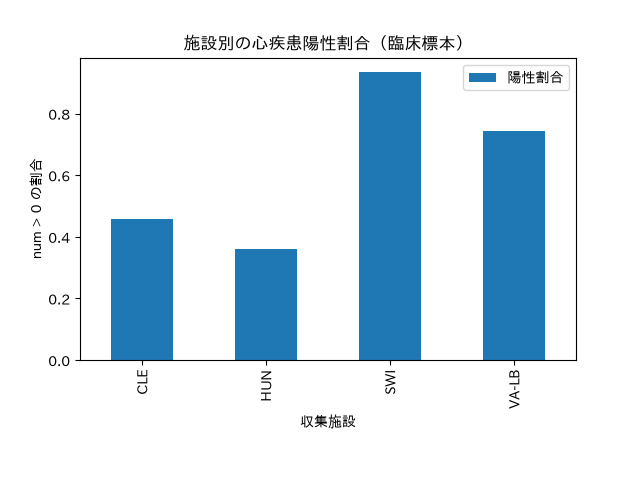

In [9]:
with execution_phase('cell-16'):
    pass
    import warnings
    import matplotlib.pyplot as plt
    from IPython.display import Image
    site_plot=df.groupby('dataset').y.mean().rename('陽性割合').reset_index()
    site_plot['dataset']=site_plot['dataset'].map({'Cleveland':'CLE','Hungary':'HUN','Switzerland':'SWI','VA Long Beach':'VA-LB'})
    with warnings.catch_warnings(record=True) as chart_warnings, plt.rc_context({'figure.subplot.bottom':0.25}):
        warnings.simplefilter('always')
        png=visualization.render_chart(site_plot,kind='bar',x='dataset',y='陽性割合',title='施設別の心疾患陽性割合（臨床標本）',xlabel='収集施設',ylabel='num > 0 の割合')
    image_output=visualization.build_image_output(png)
    display(image_output.data,raw=True)
    print('図1ラベル・凡例: 施設別の心疾患陽性割合（臨床標本） / 収集施設 / num > 0 の割合 / 陽性割合')
    print('図1警告:',[str(w.message) for w in chart_warnings])
    assert not any('Glyph' in str(w.message) for w in chart_warnings), '日本語字形の欠落'
    print('施設略号: CLE=Cleveland、HUN=Hungary、SWI=Switzerland、VA-LB=VA Long Beach')
    print('図1画像バイト数:',len(png))
    pass

図2: 主モデルの選択した調整ORと95%CI。全係数はモデル表に掲載。
図2画像バイト数: 59749


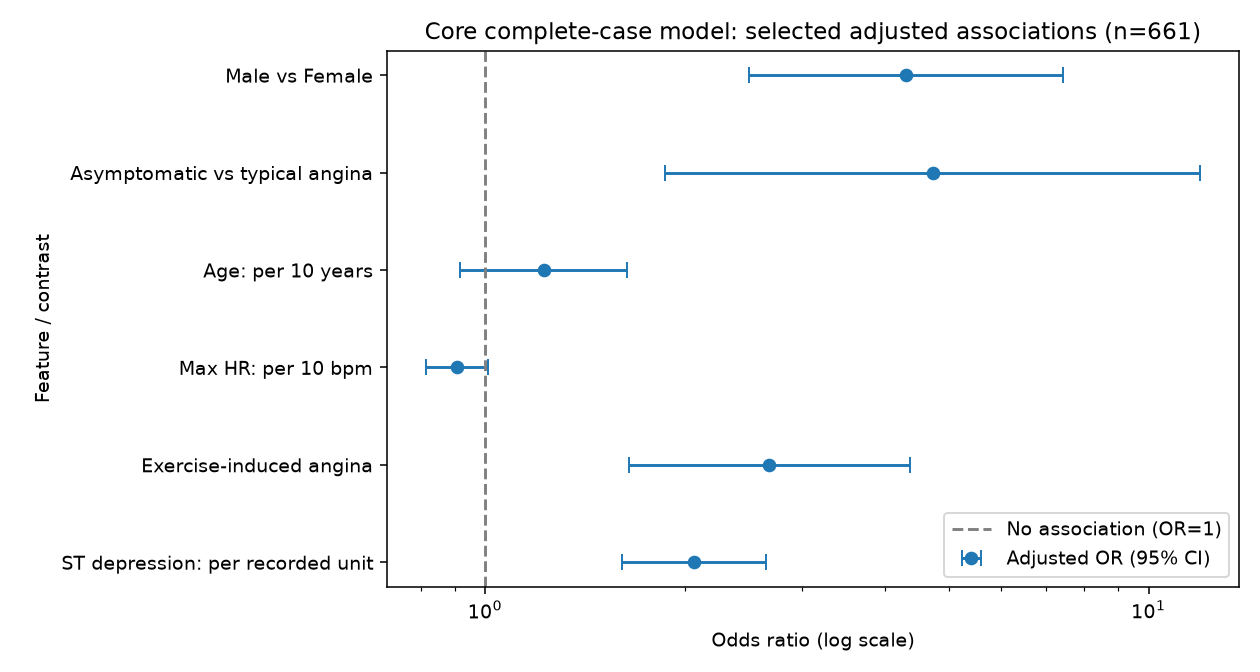

In [10]:
with execution_phase('cell-17'):
    pass
    import matplotlib.pyplot as plt
    forest=adjusted.reindex(selected_terms).copy()
    labels=['Male vs Female','Asymptomatic vs typical angina','Age: per 10 years','Max HR: per 10 bpm','Exercise-induced angina','ST depression: per recorded unit']
    fig,ax=plt.subplots(figsize=(9,4.8))
    positions=np.arange(len(forest))
    ax.errorbar(forest.OR,positions,xerr=np.vstack([forest.OR-forest.CI_low,forest.CI_high-forest.OR]),fmt='o',capsize=4,label='Adjusted OR (95% CI)')
    ax.axvline(1,color='gray',linestyle='--',label='No association (OR=1)')
    ax.set_yticks(positions,labels);ax.invert_yaxis();ax.set_xscale('log')
    ax.set_title('Core complete-case model: selected adjusted associations (n=661)')
    ax.set_xlabel('Odds ratio (log scale)');ax.set_ylabel('Feature / contrast');ax.legend(loc='lower right')
    fig.tight_layout();buffer=io.BytesIO();fig.savefig(buffer,format='png',dpi=140);plt.close(fig)
    forest_output=visualization.build_image_output(buffer.getvalue())
    display(forest_output.data,raw=True)
    print('図2: 主モデルの選択した調整ORと95%CI。全係数はモデル表に掲載。')
    print('図2画像バイト数:',len(buffer.getvalue()))
    pass

## 総合解釈・反復の結果と残る限界
最終的な係数・全前提所見を以下に再計算して記録する。数値結論の根拠manifestは最終再実行の出力に結び付ける。

In [11]:
with execution_phase('summary'):
    pass
    print('日本語の総合解釈')
    print(f'標本は{len(df)}件、num>0は{int(df.y.sum())}件（{df.y.mean():.1%}）。これは診断時の疾患有無で、将来の発症・死亡アウトカムではない。')
    print('単変量: 年齢中央値は疾患なし51歳、あり57歳。最大心拍数中央値は151対128。ST低下中央値は0対1.05（記録尺度）。性別、胸痛、狭心症、検査分類にも群差があるが、項目ごとの観測例集合が異なる。')
    print(f'主モデルは{len(cc)}完全ケース、施設と主要特徴を相互調整。年齢10歳あたりOR {adjusted.loc["age10","OR"]:.2f}（95%CI {adjusted.loc["age10","CI_low"]:.2f}–{adjusted.loc["age10","CI_high"]:.2f}）で、単変量差を調整後の独立関連と取り違えない。')
    for t in [selected_terms[0],selected_terms[1],'exang','oldpeak','chol50']:
        row=adjusted.loc[t]
        print(f'{t}: OR {row.OR:.2f}、95%CI {row.CI_low:.2f}–{row.CI_high:.2f}')
    print('交絡と調整: 年齢・性別・施設は特徴と診断の双方に関連し得る。診断所見同士は相関し、疾患の結果や診断手順の一部でもあり得る。無指定のDAGで全項目を調整しても総因果効果は同定できない。ORの非可約性・共線性も係数変化を起こすため、減衰を交絡の除去だけで説明しない。')
    print('標本選択: 男性が約79%、4施設の臨床標本で紹介・受診・検査施行の選択がある。疾患と症状が受診に影響すると受診への条件付けがコライダーバイアスを生む。母集団抽出率不明で一般住民の有病率・個人の絶対リスクに一般化できない。')
    print('欠損選択: cholの0は172件、Switzerlandの123件全てが0。0を欠損化した主モデルはSwitzerlandを全件除外する。欠損は施設と疾患割合に関連し、完全ケースが無作為に残ったという仮定を支持しない。施設内の同一定数への補完では欠落した脂質情報を回復できない。')
    print('因果限界: 横断的な診断データで曝露と疾患の時間順序不明。喫煙・服薬・家族歴などの未測定交絡、逆因果、診断所見の情報漏洩、施設・時代差がある。関連から予防効果、介入効果、将来発症率は推定しない。')
    print('反復1: cholゼロの扱いで未調整の平均差は逆転する。全施設を戻す縮小モデルではexang/oldpeakの方向維持、OR相対偏差は25%以内。ただし脂質/血糖未調整という別の推定対象でありMNARは解消しない。')
    print('反復2: Cleveland 297完全ケースでslope/ca/thal追加後、exang OR1.92（0.80–4.62）、oldpeak OR1.48（0.92–2.36）。主モデルの「独立性」は限定的。caや可逆性欠損は強い診断関連だが原因とは言えない。2重複除外によるexang/oldpeakの偏差は2%未満。')
    print(f'反復3: 同標本スプラインLR p={stats.chi2.sf(lr,delta_df):.3f}。非線形を追加すべき強い証拠はなく線形モデルAICが低いが、線形の正しさを証明しない。施設除外で胸痛ORは大きく変動しCleveland除外ではCIが1を含む。')
    print('感度3判定:',{t:{'stable':r['stable'],'max_relative_deviation':r['max_relative_deviation']} for t,r in stability3.items()})
    print('残る分析前提の全所見:',analysis_assumptions.check_manifest(assumption_manifest))
    print('前提の対応: レコード独立性は重複除外だけでは証明できず、再受診情報なし。完全ケース代表性も未解決。未検証の仮定を結論の制限として保持する。')
    print('未確定定義（unknown）:',definition_manifest.unresolved_fields())
    print('推定に留まる定義（inferred）:',[(c,k,v.value) for c,fields in definition_manifest.variables.items() for k,v in fields.items() if v.status=='inferred'])
    print('原辞書との施設件数不一致: 原辞書Cleveland303/Hungarian294に対し、このCSVはCleveland304/Hungary293。他2施設の件数は一致。移動/重複/変換由来は本CSVから特定できず、原UCIの無改変コピーとは断定しない。')
    print('定義の対応: oldpeakは記録尺度のまま解釈しmm単位と断定しない。dataset↔origin、thalch↔thalachは対応を推定した列名変更。num1–4のKaggle変換履歴は独立照合できていない。')
    print('多重比較: 単変量14項目はBHで探索的FDRを調整。主モデル/追加仕様の係数CIは点ごとの95%で同時CIではない。追加分析は同じデータを見た後に選んでおり確認的証拠ではない。')
    for filename,payload in [('data-definition-manifest.json',asdict(definition_manifest)),('analysis-assumptions-manifest.json',asdict(assumption_manifest)),('sensitivity-reports.json',{'iteration1':stability1,'iteration2':stability2,'iteration3':stability3}),('acquisition.json',acquisition)]:
        (data_dir/filename).write_text(json.dumps(payload,ensure_ascii=False,default=str,indent=2),encoding='utf-8')
    uni.to_csv(data_dir/'univariate.csv',index=False)
    adjusted.to_csv(data_dir/'adjusted-odds-ratios.csv')
    print('表監査: 全表はテキストとして保存し、分母・比較基準・CIと欠損除外方式を明記。図2とモデル表の数値一致:',np.allclose(forest.OR,adjusted.reindex(selected_terms).OR))
    pass

日本語の総合解釈
標本は920件、num>0は509件（55.3%）。これは診断時の疾患有無で、将来の発症・死亡アウトカムではない。
単変量: 年齢中央値は疾患なし51歳、あり57歳。最大心拍数中央値は151対128。ST低下中央値は0対1.05（記録尺度）。性別、胸痛、狭心症、検査分類にも群差があるが、項目ごとの観測例集合が異なる。
主モデルは661完全ケース、施設と主要特徴を相互調整。年齢10歳あたりOR 1.22（95%CI 0.92–1.63）で、単変量差を調整後の独立関連と取り違えない。
C(sex, Treatment(reference='Female'))[T.Male]: OR 4.31、95%CI 2.50–7.44
C(cp, Treatment(reference='typical angina'))[T.asymptomatic]: OR 4.73、95%CI 1.87–11.96
exang: OR 2.68、95%CI 1.65–4.37
oldpeak: OR 2.06、95%CI 1.61–2.65
chol50: OR 1.24、95%CI 1.02–1.49
交絡と調整: 年齢・性別・施設は特徴と診断の双方に関連し得る。診断所見同士は相関し、疾患の結果や診断手順の一部でもあり得る。無指定のDAGで全項目を調整しても総因果効果は同定できない。ORの非可約性・共線性も係数変化を起こすため、減衰を交絡の除去だけで説明しない。
標本選択: 男性が約79%、4施設の臨床標本で紹介・受診・検査施行の選択がある。疾患と症状が受診に影響すると受診への条件付けがコライダーバイアスを生む。母集団抽出率不明で一般住民の有病率・個人の絶対リスクに一般化できない。
欠損選択: cholの0は172件、Switzerlandの123件全てが0。0を欠損化した主モデルはSwitzerlandを全件除外する。欠損は施設と疾患割合に関連し、完全ケースが無作為に残ったという仮定を支持しない。施設内の同一定数への補完では欠落した脂質情報を回復できない。
因果限界: 横断的な診断データで曝露と疾患の時間順序不明。喫煙・服薬・家族歴などの未測定交絡、逆因果、診断所見の情報漏洩、施設・時代差がある。関連から予防効果、介入効果、将来発症率は推定しない。
反復1: cholゼ

## 使用したJupytermindモジュール
直接importして呼び出したもののみ。間接依存は含めない。Notebook作成・結論書込みはJupyter MCP上の制御Notebookから実行し、解析セルは同じJupyter kernelを使う。端末・subprocess・外部スクリプト・作業エージェントは不使用。

| モジュール | 直接呼び出した関数・クラス | 用途 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定projectの作成、データ保存先、Notebook全構成・証拠セルの直列化書込み |
| ai_data_scientist.language_router | detect_language | 日本語の確認 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, get_run_status, mark_completed, mark_failed | run状態と実行/書込み/失敗/完了の管理（失敗経路は今回最終実行では未発火） |
| ai_data_scientist.ingestion | SourceSpec, ingest | 取得済み公開CSVの読込み |
| ai_data_scientist.eda | explore | dtype、欠損、カテゴリ頻度と要約 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 定義根拠・未確定フィールドの記録 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 非因果の推定範囲、標本選択・独立性の前提 |
| ai_data_scientist.data_quality | detect_anomalies | ゼロ・範囲・カテゴリ・IDの意味的検査 |
| ai_data_scientist.cleaning | clean_dataset | IDを除いた完全重複除外の感度解析 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 仕様グリッドとORの安定性・偏差 |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語棒グラフとNotebook用PNG MIME |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実際の保存済みセル出力から根拠文字列を抽出し結論を記録 |
| ai_data_scientist.notebook_audit | audit_notebook(visual_audit=True) | 全コード・証拠・図の監査 |

統計検定・カテゴリ回帰・スプラインはSciPy/statsmodels、整形はpandas、CI図はmatplotlibを直接使用。`mcp_gateway.run_and_record`は不使用：ホストのJupyter MCP execute_cellで実行結果の全MIMEを保持し、Notebook構成の書込みにはenqueue_writeを使った。独立参照データ不在のvalidate_anomalies/dataset_validation、時間情報のない時系列機能、因果推定、目的外のAutoMLは適用しない。


## Jupytermind改善候補

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係するセル・ログ |
|---|---|---|---|---|---|---|
| ドキュメント/APIの不整合 | ai-data-scientist skill手順11の例 `lifecycle.register_run(run_id)` をそのまま実行 | 例どおりにrun登録、または必須Notebook引数を手順に明記 | register_runはnotebook_path必須でTypeError | 初期登録が止まる。Kaggle/CLI/ランナー固有ではない | 実シグネチャを確認してregister_run(run_id, handle.notebook_path) | 準備段階のエラーをdata/diagnostics.jsonのlifecycle_skill_signatureへ記録。対象setupセルに正しい呼出し |
| 可視化レイアウト/監査範囲の不足 | render_chart(kind='bar')で長い施設名をxに指定、標準縦向きラベル | ラベルが画像内に収まり、はみ出しを監査で検知 | 初回PNGの施設名が下端で切れたがvisual_auditはok=True/visual_findings=[] | 図の施設名を読み切れず、監査通過だけでは十分でない | CLE/HUN/SWI/VA-LBの短い略号と対応を出力し、matplotlib rc_contextでfigure.subplot.bottom=0.25を指定。最終画像を目視確認 | 図1セル、data/initial-site-chart-clipped.png、data/diagnostics.jsonのinitial_chart |
| 証拠探索の出力型互換性不足 | MCPでprintした集計結果はstream.text、execution_count=11、陽性509が保存済み | stream.textも実行済み根拠として検索し、対応するrecord_insightとaudit_notebookが受理 | _find_evidence_cellはoutput.dataのみ探索しEvidenceMissingError。対象セル存在・509存在を確認 | 正しいMCP実行結果から結論を書けない。Notebook側の出力型に対するJupytermindの制限でありKaggleやランナーの障害ではない | 計算値をdisplay_dataのtext/plainにも実際に出力して登録。出力を捏造・後付け改変せず専用証拠セルを実行 | 総合解釈streamセル・証拠互換セル。data/diagnostics.jsonのevidence_stream_gap |

上記は改善候補であり今回ソースは変更していない。初回の親ディレクトリ未作成によるuse_notebook失敗はJupyter MCP準備、事前slugが検索1ページにない問題は選択コード、metadataのinfo入れ子を見落とした問題は呼出し側の解析であり、Jupytermindに帰責しない。認証は成功しトークンは出力せず、ベンチマークランナーの障害は観測していない。



**連携上の別現象（帰責未確定）:** 最終セルの実行中にenqueue_writeで同じNotebookを書き直すと、カーネル側のcompletedとsidecarは生成されたがMCP側でそのセルの出力・実行番号が保存されなかった。Jupytermindの書込みとJupyter MCPの保存の相互作用として記録し、単独モジュールの不具合とは断定しない。実行中の対象Notebookを変更せず、別の制御Notebookから書込み・証拠番号同期を行い、その後に読み取り専用監査セルを実行することで回避。data/diagnostics.jsonのself_write_integration参照。将来カーネル再起動後に再実行する場合も、証拠manifestの番号同期は対象Notebookの実行外で行う。

In [15]:
with execution_phase('evidence_display'):
    evidence_payload={
        'n':len(df),'positive':int(df.y.sum()),'positive_pct':round(df.y.mean()*100,1),
        'age_median0':float(df.loc[df.y.eq(0),'age'].median()),'age_median1':float(df.loc[df.y.eq(1),'age'].median()),
        'main_n':len(cc),'age_or':round(float(adjusted.loc['age10','OR']),2),
        'male_or':round(float(adjusted.loc[selected_terms[0],'OR']),2),'cp_or':round(float(adjusted.loc[selected_terms[1],'OR']),2),
        'exang_or':round(float(adjusted.loc['exang','OR']),2),'oldpeak_or':round(float(adjusted.loc['oldpeak','OR']),2),
        'zero_chol_count':int(raw.chol.eq(0).sum()),'switzerland_n':int(raw.dataset.eq('Switzerland').sum()),
        'cleveland_ext_n':len(cleveland_cc),'cleveland_exang_or':round(float(np.exp(cleveland_ext.params['exang'])),2),
        'cleveland_oldpeak_or':round(float(np.exp(cleveland_ext.params['oldpeak'])),2),
        'cp_max_relative_deviation':stability3[selected_terms[1]]['max_relative_deviation'],
        'male_max_relative_deviation':stability3[selected_terms[0]]['max_relative_deviation'],
        'exang_max_relative_deviation':stability3['exang']['max_relative_deviation'],
        'sampling_limits':'臨床標本、男性約79%、受診・検査・完全ケース選択、抽出率不明',
        'causal_limits':'時間順序不明、未測定交絡、逆因果、診断構成要素、OR非可約性。介入効果は識別不能',
        'assumption_findings':[asdict(x) for x in analysis_assumptions.check_manifest(assumption_manifest)]
    }
    display({'text/plain':json.dumps(evidence_payload,ensure_ascii=False,indent=2)},raw=True)
    print('証拠互換性: Jupytermindの探索はstream.textを参照しないため、再計算した結果をdisplay_dataのtext/plainとして提示。過去のセル出力は改変していない。')


証拠互換性: Jupytermindの探索はstream.textを参照しないため、再計算した結果をdisplay_dataのtext/plainとして提示。過去のセル出力は改変していない。


{
  "n": 920,
  "positive": 509,
  "positive_pct": 55.3,
  "age_median0": 51.0,
  "age_median1": 57.0,
  "main_n": 661,
  "age_or": 1.22,
  "male_or": 4.31,
  "cp_or": 4.73,
  "exang_or": 2.68,
  "oldpeak_or": 2.06,
  "zero_chol_count": 172,
  "switzerland_n": 123,
  "cleveland_ext_n": 297,
  "cleveland_exang_or": 1.92,
  "cleveland_oldpeak_or": 1.48,
  "cp_max_relative_deviation": 0.7309462657877843,
  "male_max_relative_deviation": 0.3222130356278573,
  "exang_max_relative_deviation": 0.12456724411356614,
  "sampling_limits": "臨床標本、男性約79%、受診・検査・完全ケース選択、抽出率不明",
  "causal_limits": "時間順序不明、未測定交絡、逆因果、診断構成要素、OR非可約性。介入効果は識別不能",
  "assumption_findings": [
    {
      "code": "unresolved_conclusion_critical_assumption",
      "severity": "warning",
      "message": "Conclusion-critical assumption 'independent' has status 'assumed', not verified/tested.",
      "assumption_id": "independent"
    },
    {
      "code": "unresolved_conclusion_critical_assumption",
      "severity": "warning",
 

## 証拠に基づく結論

対象は4施設920レコード、心疾患陽性は509件（55.3%）。num=0を陰性、1–4を陽性に集約した診断時のアウトカムであり、将来発症・死亡ではない。UCI辞書とKaggle説明を参照したが変換履歴の患者単位照合は未実施。

```evidence
{"execution_count":15,"cited_value":"509","claim_type":"descriptive"}
```

単変量では疾患陽性群の年齢中央値57歳、陰性群51歳という差があるが、施設・主要特徴を相互調整した年齢10歳あたりORは1.22（95%CI 0.92–1.63）。群差を調整後の独立関連と取り違えず、CIが1を含むことを「効果がない証明」ともしない。

```evidence
{"execution_count":15,"cited_value":"1.22","claim_type":"associational"}
```

661完全ケースの主モデルでは、男性（女性比OR4.31）、asymptomatic胸痛型（typical angina比OR4.73）、運動誘発狭心症（OR2.68、95%CI 1.65–4.37）、ST低下（記録尺度1増加あたりOR2.06）が陽性と関連した。これらは診断所見の相互調整関連であり、危険因子・予防介入効果を同定したものではない。

```evidence
{"execution_count":15,"cited_value":"2.68","claim_type":"associational"}
```

コレステロール0は172件、Switzerlandの123件全てが0だった。生理的な真値とみなさず欠損化した主解析では同施設が全件脱落する。0を含めた未調整平均差と0を欠損化した差は方向が逆であり、「低コレステロールが心疾患を引き起こす」という解釈は支持しない。代表性・欠損機構は未解決である。

```evidence
{"execution_count":15,"cited_value":"172","claim_type":"descriptive"}
```

Clevelandの同じ297完全ケースでslope/ca/thalを追加すると、運動誘発狭心症ORは1.92（95%CI 0.80–4.62）、ST低下ORは1.48（0.92–2.36）。主モデルから「すべての検査所見から独立」とは結論できない。追加項目は疾患の結果・診断構成要素かもしれず、減衰を因果的な媒介効果と解釈しない。

```evidence
{"execution_count":15,"cited_value":"1.92","claim_type":"associational"}
```

施設除外・非線形仕様の感度分析で、胸痛型ORの最大相対偏差は0.7309462657877843（約73.1%）でstable=False。Cleveland除外ではOR1.27、CI 0.24–6.62となり施設依存が大きい。男性ORも最大偏差32.2%でstable=False。一方、運動誘発狭心症は最大偏差12.5%でstable=Trueだが、指定仕様・25%閾値に限る判定である。

```evidence
{"execution_count":15,"cited_value":"0.7309462657877843","claim_type":"associational"}
```

920件は男性約79%の臨床診断標本で、紹介・受診・検査施行と完全ケースへの選択がある。未測定の喫煙・服薬・家族歴、時間順序不明と逆因果、ORの非可約性、同じデータを見た後の探索を考慮すると、一般人口の有病率・絶対リスク・介入効果には一般化できない。レコード独立性と完全ケース代表性は前提manifestで未解決と記録した。

```evidence
{"execution_count":15,"cited_value":"920","claim_type":"descriptive"}
```

## 最終監査とライフサイクル
全コードセルをJupyter MCPで上から再実行し、保存後にvisual_audit=Trueで再監査する。状態はdata/lifecycle-events.jsonlとdata/final-audit.jsonにも永続化する。監査のokは統計的仮定の正しさや図の全レイアウトの保証ではない。

**保存後の監査:** 全13コードセル実行済み、エラー0、証拠付き結論7件、図2件。visual_audit=Trueで所見なし、ライフサイクルcompleted・実行/書込みカウンタ0。末尾セル自身の実行中除外による一時的警告は保存後の外部監査で消失。最終報告はNotebook metadata.final_audit/final_lifecycleとdata/final-audit.jsonに保存。

In [21]:
lifecycle.mark_execution_start(run_id)
record_lifecycle('execution_start',phase='final_audit')
try:
    report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('notebook_audit:',json.dumps(asdict(report),ensure_ascii=False,default=str,indent=2))
    print('audit_ok:',report.ok)
    if not report.ok:
        lifecycle.mark_failed(run_id)
        record_lifecycle('failed',phase='final_audit')
        raise RuntimeError('Notebook監査不合格')
finally:
    lifecycle.mark_execution_end(run_id)
    record_lifecycle('execution_end',phase='final_audit')
lifecycle.mark_completed(run_id)
record_lifecycle('completed')
status=asdict(lifecycle.get_run_status(run_id))
print('最終ライフサイクル:',json.dumps(status,ensure_ascii=False,indent=2))
(data_dir/'final-audit.json').write_text(json.dumps({'report':asdict(report),'ok':report.ok,'lifecycle':status},ensure_ascii=False,default=str,indent=2),encoding='utf-8')
assert status['state']=='completed' and status['active_cell_executions']==0 and status['pending_notebook_writes']==0


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-33-heart-disease/notebooks/kaggle-v020-kaggle-exp-33-heart-disease.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 13,
  "executed_code_cell_count": 12,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    16,
    17
  ],
  "insight_cell_count": 7,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 32
    }
  ],
  "visual_findings": []
}
audit_ok: True
最終ライフサイクル: {
  "run_id": "v020-exp-33",
  "state": "completed",
  "active_cell_executions": 0,
  "pending_notebook_writes": 0,
  "locks_held": 0,
  "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-33-heart-disease/notebooks/kaggle-v020-kaggle-exp-33-heart-disease.ipynb",
  "reason": null
}
